In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Load  dataset
df = pd.read_csv("Arrests and Strip Searches.csv") 
df

,_id,Arrest_Year,Arrest_Month,EventID,ArrestID,PersonID,Perceived_Race,Sex,Age_group__at_arrest_,Youth_at_arrest__under_18_years,...,Actions_at_arrest___Resisted__d,Actions_at_arrest___Mental_inst,Actions_at_arrest___Assaulted_o,Actions_at_arrest___Cooperative,SearchReason_CauseInjury,SearchReason_AssistEscape,SearchReason_PossessWeapons,SearchReason_PossessEvidence,ItemsFound,ObjectId
0,1,2020,July-Sept,1005907,6017884.0,326622,White,M,Aged 35 to 44 years,Not a youth,...,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1
1,2,2020,July-Sept,1014562,6056669.0,326622,White,M,Aged 35 to 44 years,Not a youth,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
2,3,2020,Oct-Dec,1029922,6057065.0,326622,Unknown or Legacy,M,Aged 35 to 44 years,Not a youth,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
3,4,2021,Jan-Mar,1052190,6029059.0,327535,Black,M,Aged 25 to 34 years,Not a youth,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
4,5,2021,Jan-Mar,1015512,6040372.0,327535,South Asian,M,Aged 25 to 34 years,Not a youth,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65271,65272,2021,Oct-Dec,1055609,6044336.0,316123,Indigenous,F,Aged 25 to 34 years,Not a youth,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65272
65272,65273,2021,Oct-Dec,1032758,6031692.0,307736,South Asian,M,Aged 35 to 44 years,Not a youth,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65273
65273,65274,2021,Oct-Dec,1021067,6064396.0,324057,White,F,Aged 45 to 54 years,Not a youth,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65274
65274,65275,2021,Oct-Dec,1008998,6008662.0,331870,Unknown or Legacy,M,Aged 17 years and under,Youth (aged 17 years and under),...,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,65275


In [11]:
def get_season(month_range):
    if month_range == 'Apr-June':
        return 'Spring'
    elif month_range == 'Oct-Dec':
        return 'Fall'
    else:
        return None  # Ignore other month ranges

# Apply to create a new 'Season' column
df["Season"] = df["Arrest_Month"].apply(get_season)

# Filter out rows that aren't Spring or Fall
df = df[df["Season"].notnull()]
# Filter only 2020 or 2021
df = df[df["Arrest_Year"].isin([2020, 2021])]

In [12]:
# Recode racial categories
race_mapping = {
    "Black": "Black",
    "East/Southeast Asian": "Asian",
    "South Asian": "Asian",
    "White": "White",
    "Indigenous": "Other",
    "Latino": "Other",
    "Middle-Eastern": "Other",
    "Unknown or Legacy": "Other"
}

df["Race_Grouped"] = df["Perceived_Race"].map(race_mapping)

df

,_id,Arrest_Year,Arrest_Month,EventID,ArrestID,PersonID,Perceived_Race,Sex,Age_group__at_arrest_,Youth_at_arrest__under_18_years,...,Actions_at_arrest___Assaulted_o,Actions_at_arrest___Cooperative,SearchReason_CauseInjury,SearchReason_AssistEscape,SearchReason_PossessWeapons,SearchReason_PossessEvidence,ItemsFound,ObjectId,Season,Race_Grouped
2,3,2020,Oct-Dec,1029922,6057065.0,326622,Unknown or Legacy,M,Aged 35 to 44 years,Not a youth,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,Fall,Other
5,6,2021,Apr-June,1019145,6060688.0,327535,South Asian,M,Aged 25 to 34 years,Not a youth,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,6,Spring,Asian
9,10,2021,Apr-June,1012287,6004570.0,330778,Black,M,Aged 25 to 34 years,Not a youth,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,Spring,Black
10,11,2021,Apr-June,1056655,6032326.0,330778,Black,M,Aged 25 to 34 years,Not a youth,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,11,Spring,Black
11,12,2021,Apr-June,1040382,6054934.0,330778,Black,M,Aged 25 to 34 years,Not a youth,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,Spring,Black
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65271,65272,2021,Oct-Dec,1055609,6044336.0,316123,Indigenous,F,Aged 25 to 34 years,Not a youth,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65272,Fall,Other
65272,65273,2021,Oct-Dec,1032758,6031692.0,307736,South Asian,M,Aged 35 to 44 years,Not a youth,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65273,Fall,Asian
65273,65274,2021,Oct-Dec,1021067,6064396.0,324057,White,F,Aged 45 to 54 years,Not a youth,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65274,Fall,White
65274,65275,2021,Oct-Dec,1008998,6008662.0,331870,Unknown or Legacy,M,Aged 17 years and under,Youth (aged 17 years and under),...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,65275,Fall,Other


In [15]:

# Group by year, season, and perceived race
grouped = df.groupby(["Arrest_Year", "Season", "Perceived_Race"]).size().reset_index(name="Count")

# Normalize race categories for consistent display
race_order = ["Asian", "Black", "Other", "White"]
grouped["Perceived_Race"] = grouped["Perceived_Race"].apply(lambda r: r if r in race_order else "Other")

# Define race order consistent with your original plot
colors = ["#d95f02", "#a50f15", "#b2b267", "#377eb8"]  # consistent colors for race

# Group data for plotting
grouped = df.groupby(["Arrest_Year", "Season", "Race_Grouped"]).size().reset_index(name="Count")




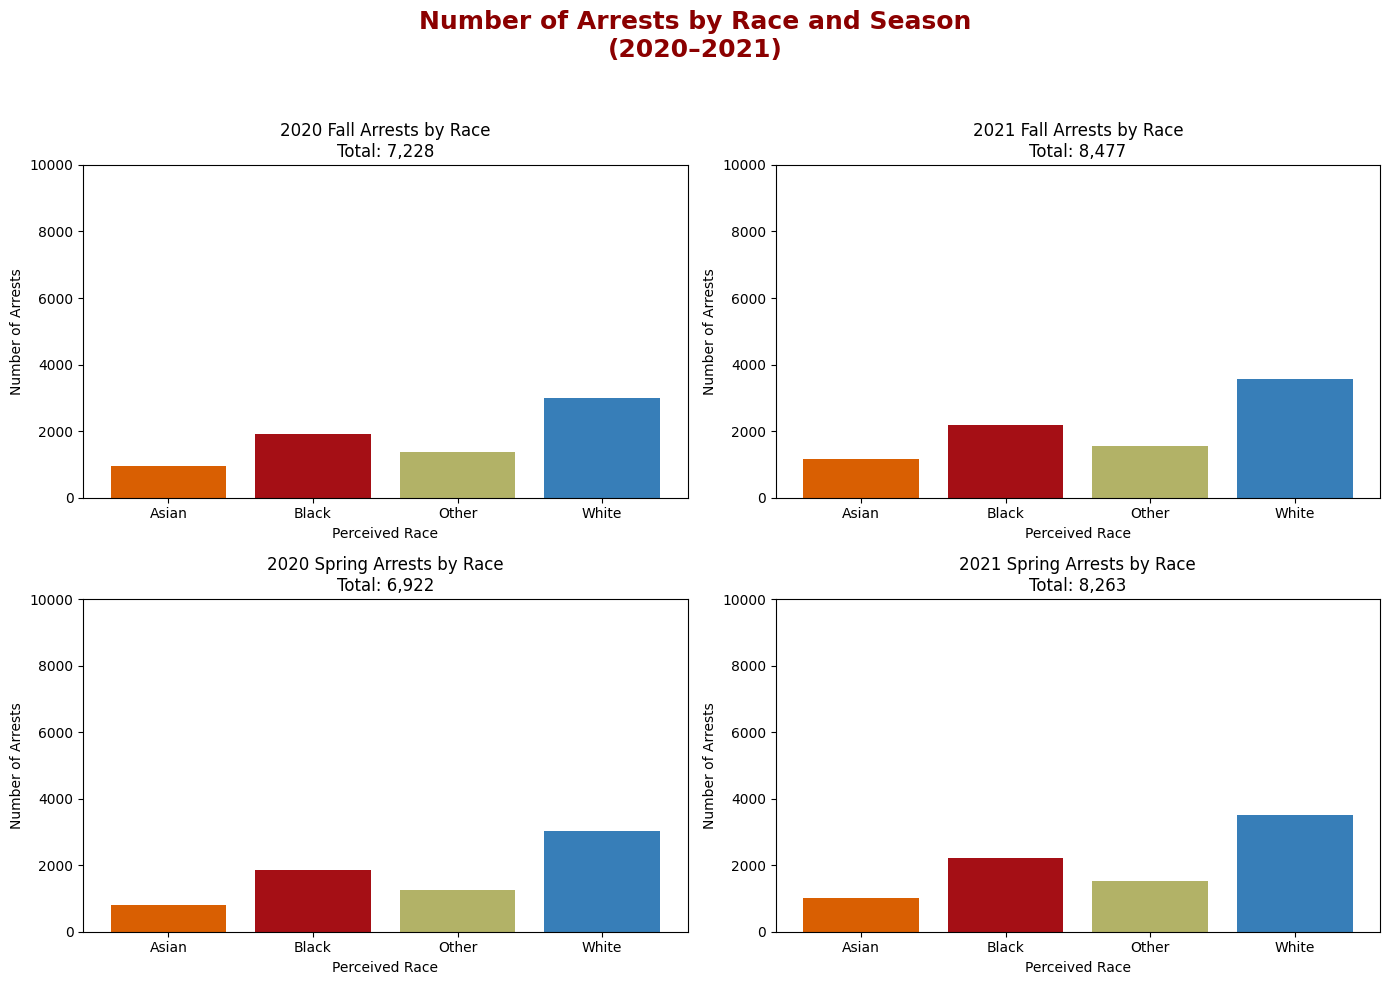

In [16]:

# Create 2x2 subplot
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Number of Arrests by Race and Season\n(2020–2021)", fontsize=18, fontweight='bold', color="#8B0000")

seasons = [("2020", "Fall"), ("2021", "Fall"), ("2020", "Spring"), ("2021", "Spring")]
positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

for (year, season), pos in zip(seasons, positions):
    ax = axs[pos]
    data = grouped[(grouped["Arrest_Year"] == int(year)) & (grouped["Season"] == season)]
    
    # Ensure all race categories are present
    data = data.set_index("Race_Grouped").reindex(race_order, fill_value=0).reset_index()

    ax.bar(data["Race_Grouped"], data["Count"], color=colors)
    total = data["Count"].sum()
    ax.set_title(f"{year} {season} Arrests by Race\nTotal: {total:,}", fontsize=12)
    ax.set_ylim(0, 10000)
    ax.set_ylabel("Number of Arrests")
    ax.set_xlabel("Perceived Race")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()